# Vergleich: Hautglättung


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, spearmanr


In [2]:
DATA_DIR = Path('../../data')

INPUT_CSV = DATA_DIR / '04_analysis_results' / 'visual_features' / '07_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_skin_smoothness.csv'
print(f'Reading {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)

print('Selected sigma values:', df['skin_selected_sigma'].dropna().unique()[:10])
print(df[['influencer_type', 'skin_smoothness_highpass_index', 'skin_smoothness_dog_index', 'detected_skin_face_frames']].groupby('influencer_type').agg(['count', 'mean', 'std']))


Reading ../../data/04_analysis_results/visual_features/07_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_skin_smoothness.csvSelected sigma values: [2.]                skin_smoothness_highpass_index                      \                                         count      mean       std   influencer_type                                                      ai                                         249  0.019237  0.017889   real                                       246  0.019407  0.025330                   skin_smoothness_dog_index                      \                                    count      mean       std   influencer_type                                                 ai                                    249  0.057831  0.036710   real                                  246  0.061254  0.042194                   detected_skin_face_frames                                                         count    mean        std  influencer_type                                               ai 

In [3]:
FRAME_ROOT = DATA_DIR / '02_media/stratified_sample/frames'

def get_video_id(row):
    return str(row.get('id') or row.get('video_id'))

def first_frame_path(video_id: str):
    folder = FRAME_ROOT / video_id
    if not folder.is_dir():
        return None
    frames = sorted(folder.glob('*.jpeg'))
    if not frames:
        frames = sorted(folder.glob('*.jpg'))
    if not frames:
        return None
    return frames[len(frames) // 2]

def load_image(path):
    import cv2
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


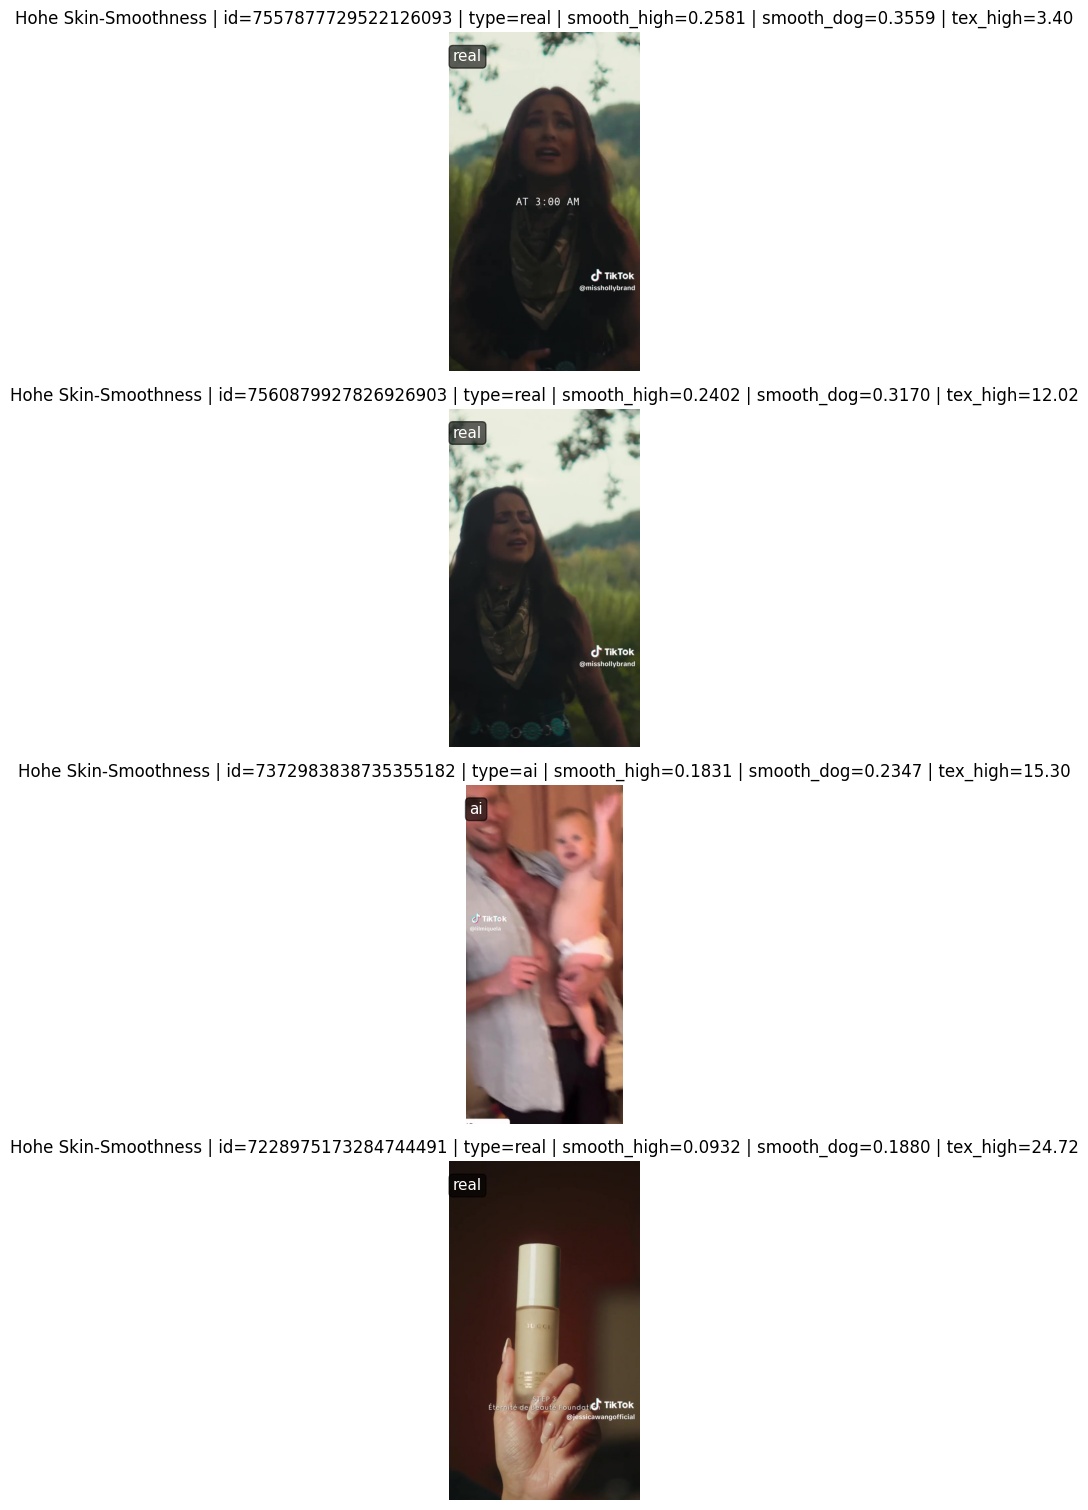

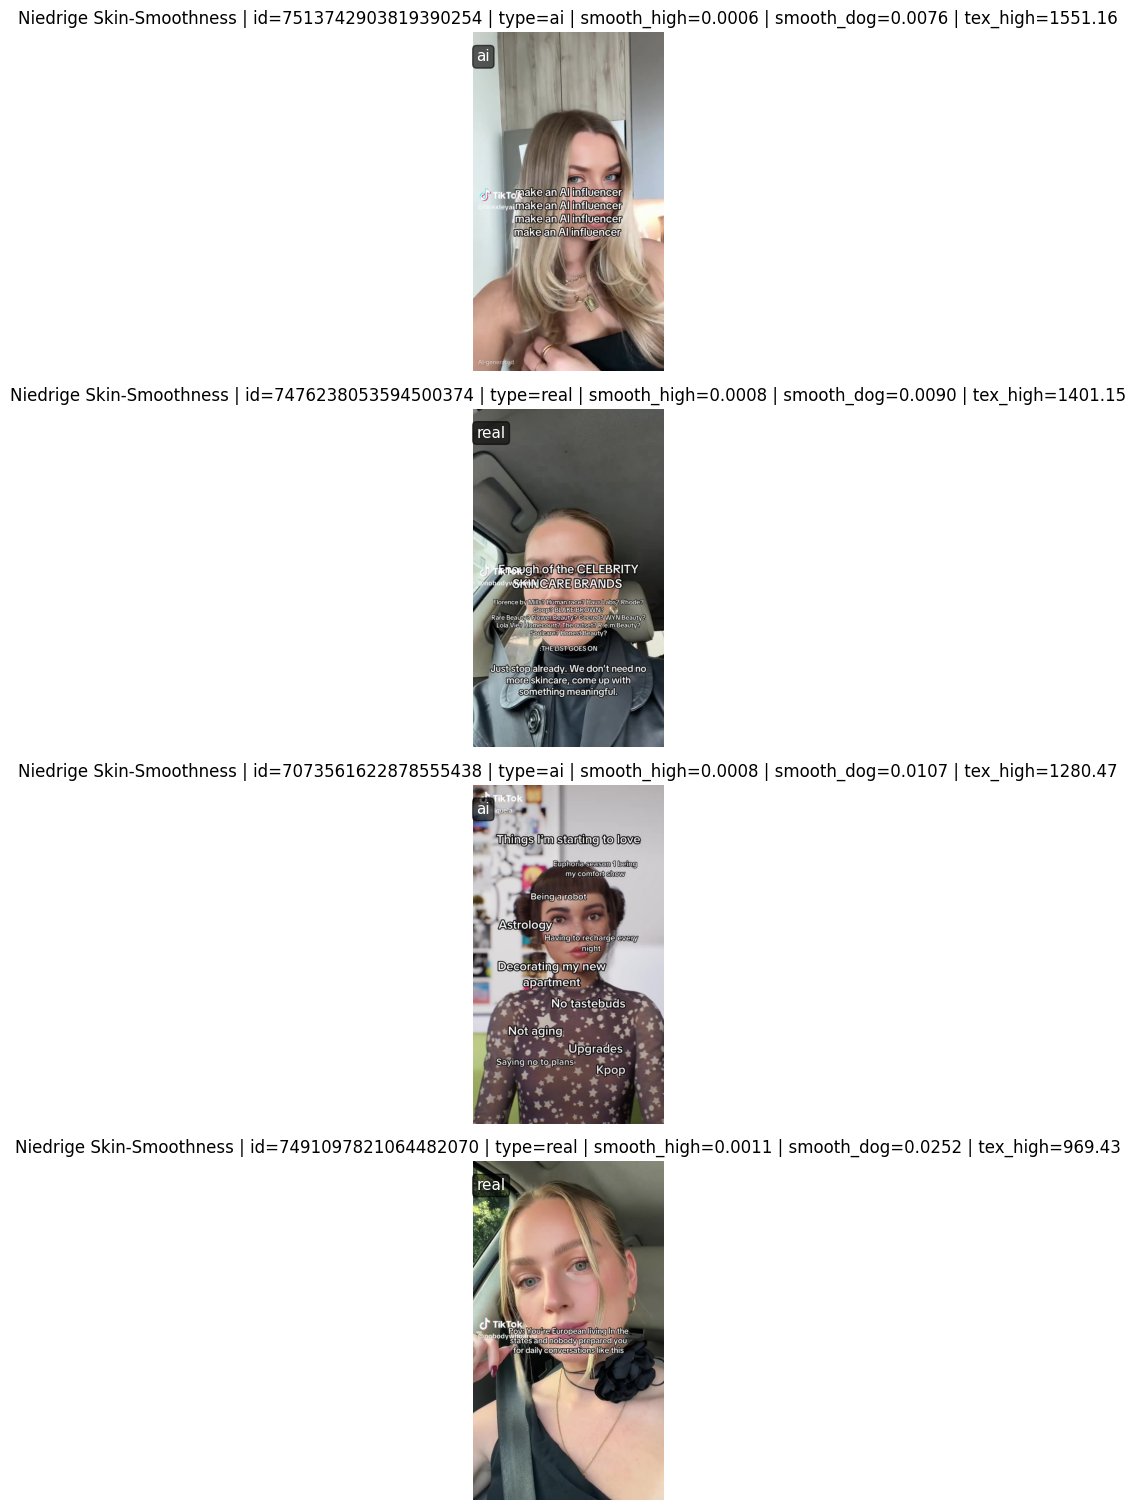

In [4]:
# Beispiele mit hoher und niedriger Hautglättung anzeigen
_df = df.dropna(subset=['skin_smoothness_highpass_index']).copy()

def pick_examples(df_sorted, n=4):
    rows = []
    for _, row in df_sorted.iterrows():
        vid = get_video_id(row)
        fp = first_frame_path(vid)
        if fp is None:
            continue
        row = row.copy()
        row['frame_path'] = fp
        rows.append(row)
        if len(rows) >= n:
            break
    return rows

def show_examples(rows, title):
    if not rows:
        print(f'No frames found for {title}')
        return

    plt.figure(figsize=(12, 3.8 * len(rows)))
    for i, row in enumerate(rows, 1):
        img = load_image(row['frame_path'])
        ax = plt.subplot(len(rows), 1, i)
        if img is not None:
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'Image load failed', ha='center', va='center')
            ax.axis('off')

        s_high = row['skin_smoothness_highpass_index']
        s_dog = row.get('skin_smoothness_dog_index', np.nan)
        t_high = row.get('skin_texture_highpass_var', np.nan)
        inf = row.get('influencer_type', '')
        vid = get_video_id(row)
        ax.text(0.02, 0.95, f'{inf}', transform=ax.transAxes, ha='left', va='top',
                fontsize=11, color='white',
                bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.6))
        ax.set_title(
            f'{title} | id={vid} | type={inf} | smooth_high={s_high:.4f} | smooth_dog={s_dog:.4f} | tex_high={t_high:.2f}'
        )

    plt.tight_layout()
    plt.show()

high_smooth = pick_examples(_df.sort_values('skin_smoothness_highpass_index', ascending=False), n=4)
low_smooth = pick_examples(_df.sort_values('skin_smoothness_highpass_index', ascending=True), n=4)

show_examples(high_smooth, 'Hohe Skin-Smoothness')
show_examples(low_smooth, 'Niedrige Skin-Smoothness')


In [3]:
summary = df.groupby('influencer_type')[[
    'skin_smoothness_highpass_index',
    'skin_smoothness_dog_index',
    'skin_texture_highpass_var',
    'skin_texture_dog_var',
    'detected_skin_face_frames',
]].describe().round(4)
display(summary)


skin_smoothness_highpass_index                          \
                                         count    mean     std     min   
influencer_type                                                          
ai                                       249.0  0.0192  0.0179  0.0006   
real                                     246.0  0.0194  0.0253  0.0008   

                                                skin_smoothness_dog_index  \
                    25%     50%     75%     max                     count   
influencer_type                                                             
ai               0.0094  0.0144  0.0243  0.1831                     249.0   
real             0.0075  0.0136  0.0239  0.2581                     246.0   

                         ... skin_texture_dog_var            \
                   mean  ...                  75%       max   
influencer_type          ...                                  
ai               0.0578  ...              32.4871  130.8266   
real             0.0613  ...              36.0010  114.8357   

                detected_skin_face_frames                                   \
                                    count    mean      std  min  25%   50%   
influencer_type                                                              
ai                                  250.0  16.132  15.1468  0.0  8.0  11.0   
real                                250.0  36.000  47.2749  0.0  8.0  17.0   

                               
                   75%    max  
influencer_type                
ai               18.00  118.0  
real             46.75  326.0  

[2 rows x 40 columns]

/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_77601/14910140.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_77601/14910140.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_77601/14910140.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


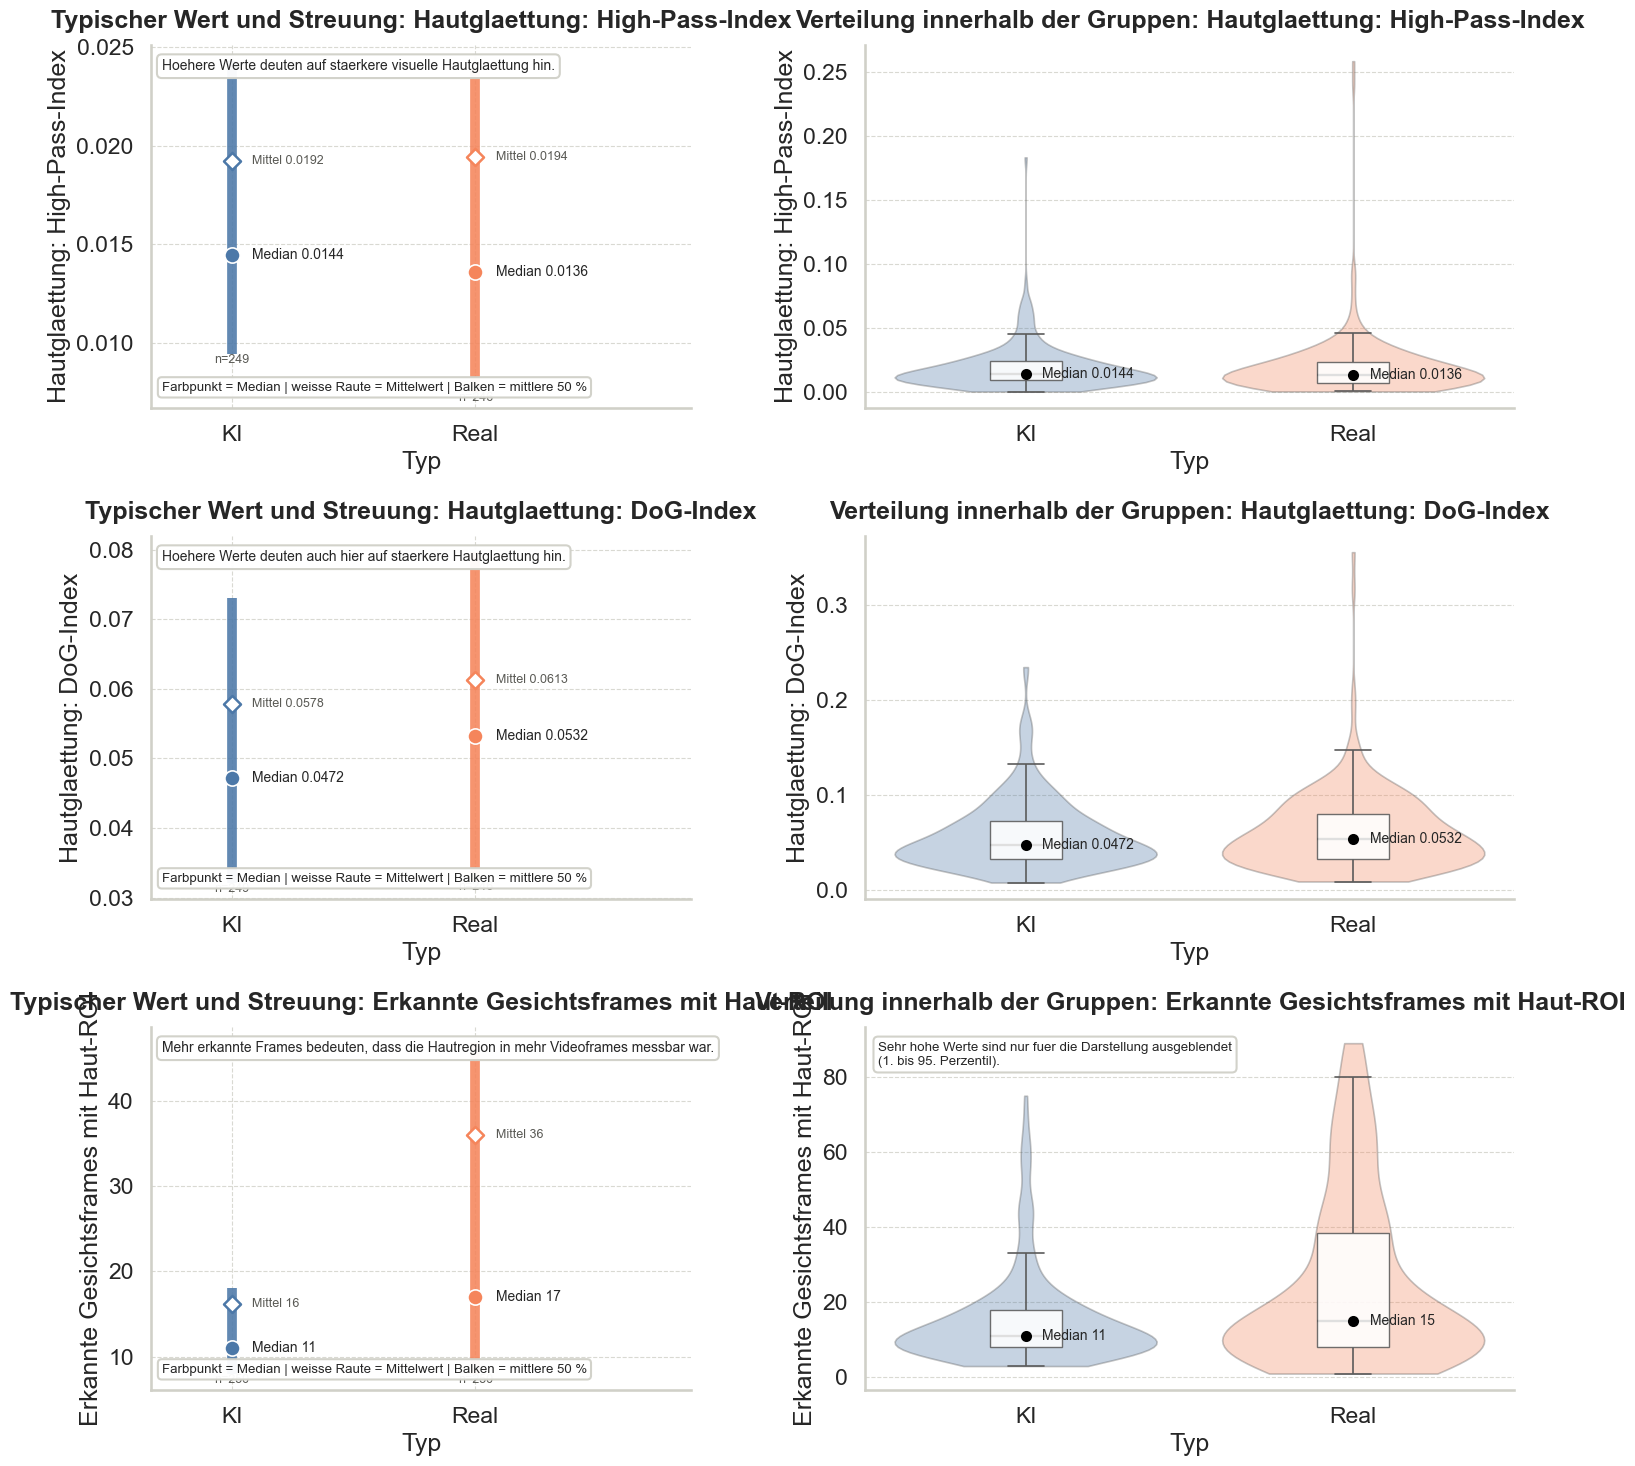

In [9]:
# Visualisierung der Hautglättung
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
ORDER = ['KI', 'Real']

plot_label_map = {
    'skin_smoothness_highpass_index': 'Hautglaettung: High-Pass-Index',
    'skin_smoothness_dog_index': 'Hautglaettung: DoG-Index',
    'detected_skin_face_frames': 'Erkannte Gesichtsframes mit Haut-ROI',
}

plot_note_map = {
    'skin_smoothness_highpass_index': 'Höhere Werte deuten auf staerkere visuelle Hautglaettung hin.',
    'skin_smoothness_dog_index': 'Höhere Werte deuten auch hier auf staerkere Hautglaettung hin.',
    'detected_skin_face_frames': 'Mehr erkannte Frames bedeuten, dass die Hautregion in mehr Videoframes messbar war.',
}

value_fmt = {
    'skin_smoothness_highpass_index': '{:.4f}',
    'skin_smoothness_dog_index': '{:.4f}',
    'detected_skin_face_frames': '{:.0f}',
}

metrics = [
    'skin_smoothness_highpass_index',
    'skin_smoothness_dog_index',
    'detected_skin_face_frames',
]

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])

fig, axes = plt.subplots(3, 2, figsize=(15.2, 15.0), gridspec_kw={'width_ratios': [1.0, 1.2]})

for row_idx, metric in enumerate(metrics):
    metric_df = df_plot[['typ', metric]].dropna().copy()
    if metric_df.empty:
        continue

    display_df = metric_df.copy()
    if metric == 'detected_skin_face_frames' and len(display_df) >= 10:
        lower = display_df[metric].quantile(0.01)
        upper = display_df[metric].quantile(0.95)
        display_df = display_df[display_df[metric].between(lower, upper)]

    summary = (
        metric_df.groupby('typ')[metric]
        .agg(q1=lambda x: x.quantile(0.25), median='median', q3=lambda x: x.quantile(0.75), mean='mean', n='count')
        .reindex(ORDER)
    )

    ax_left = axes[row_idx, 0]
    x_positions = np.array([0.00, 0.36])

    for pos, grp in zip(x_positions, ORDER):
        if grp not in summary.index or pd.isna(summary.loc[grp, 'median']):
            continue
        color = PALETTE_COLOR[grp]
        q1 = summary.loc[grp, 'q1']
        med = summary.loc[grp, 'median']
        q3 = summary.loc[grp, 'q3']
        mean = summary.loc[grp, 'mean']
        n_obs = int(summary.loc[grp, 'n'])

        ax_left.vlines(pos, q1, q3, color=color, linewidth=7, alpha=0.88, zorder=2)
        ax_left.scatter(pos, med, s=120, color=color, edgecolor='white', linewidth=1.2, zorder=3)
        ax_left.scatter(pos, mean, s=75, color='white', edgecolor=color, linewidth=1.8, marker='D', zorder=4)
        ax_left.text(pos + 0.03, med, f"Median {value_fmt[metric].format(med)}", va='center', ha='left', fontsize=10)
        ax_left.text(pos + 0.03, mean, f"Mittel {value_fmt[metric].format(mean)}", va='center', ha='left', fontsize=9, color='#5a5a55')
        ax_left.text(pos, q1, f"n={n_obs}", va='top', ha='center', fontsize=9, color='#5a5a55')

    ax_left.set_xlim(-0.12, 0.68)
    ax_left.set_xticks(x_positions)
    ax_left.set_xticklabels(ORDER)
    ax_left.set_ylabel(plot_label_map[metric])
    ax_left.set_xlabel('Typ')
    ax_left.set_title(f"Typischer Wert und Streuung: {plot_label_map[metric]}", pad=12, weight='semibold')
    ax_left.text(
        0.02,
        0.04,
        'Farbpunkt = Median | weisse Raute = Mittelwert | Balken = mittlere 50 %',
        transform=ax_left.transAxes,
        ha='left',
        va='bottom',
        fontsize=9.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
    )
    ax_left.text(
        0.02,
        0.96,
        plot_note_map[metric],
        transform=ax_left.transAxes,
        ha='left',
        va='top',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
    )

    ax_right = axes[row_idx, 1]
    sns.violinplot(
        data=display_df,
        x='typ',
        y=metric,
        order=ORDER,
        palette=PALETTE_COLOR,
        inner=None,
        cut=0,
        linewidth=1.2,
        saturation=0.95,
        alpha=0.32,
        ax=ax_right,
    )
    sns.boxplot(
        data=display_df,
        x='typ',
        y=metric,
        order=ORDER,
        width=0.22,
        fliersize=0,
        boxprops={'facecolor': 'white', 'alpha': 0.88, 'zorder': 3},
        whiskerprops={'linewidth': 1.2},
        capprops={'linewidth': 1.2},
        medianprops={'color': 'black', 'linewidth': 1.7},
        ax=ax_right,
    )

    medians = display_df.groupby('typ')[metric].median().reindex(ORDER)
    for x_pos, grp in zip(range(len(ORDER)), ORDER):
        med_val = medians.get(grp)
        if pd.isna(med_val):
            continue
        ax_right.scatter(x_pos, med_val, c='black', s=42, zorder=5)
        ax_right.text(x_pos + 0.05, med_val, f"Median {value_fmt[metric].format(med_val)}", va='center', fontsize=10)

    ax_right.set_title(f"Verteilung innerhalb der Gruppen: {plot_label_map[metric]}", pad=12, weight='semibold')
    ax_right.set_xlabel('Typ')
    ax_right.set_ylabel(plot_label_map[metric])

    if metric == 'detected_skin_face_frames' and len(metric_df) >= 10:
        ax_right.text(
            0.02,
            0.96,
            'Sehr hohe Werte sind nur für die Darstellung ausgeblendet\n(1. bis 95. Perzentil).',
            transform=ax_right.transAxes,
            ha='left',
            va='top',
            fontsize=9.5,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
        )

for ax in np.ravel(axes):
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()




In [6]:
# Signifikanztest laut Tabelle: Mann-Whitney-U für smoothness_index
metric = 'skin_smoothness_highpass_index' if 'skin_smoothness_highpass_index' in df.columns else ('skin_smoothness_dog_index' if 'skin_smoothness_dog_index' in df.columns else None)

results = []
if metric is not None:
    ai_vals = df.loc[df['influencer_type'] == 'ai', metric].dropna()
    real_vals = df.loc[df['influencer_type'] == 'real', metric].dropna()

    if len(ai_vals) > 0 and len(real_vals) > 0:
        u_stat, u_p = mannwhitneyu(ai_vals, real_vals, alternative='two-sided')
        results.append({
            'metric': metric,
            'n_ai': len(ai_vals),
            'n_real': len(real_vals),
            'mean_ai': ai_vals.mean(),
            'mean_real': real_vals.mean(),
            'median_ai': ai_vals.median(),
            'median_real': real_vals.median(),
            'u_stat': u_stat,
            'u_p': u_p,
        })

results_df = pd.DataFrame(results).round(4)
display(results_df)


,metric,n_ai,n_real,mean_ai,mean_real,median_ai,median_real,u_stat,u_p
0,skin_smoothness_highpass_index,249,246,0.0192,0.0194,0.0144,0.0136,32105.0,0.3531


In [ ]:
# Zusammenhang zwischen Hautglättung und Engagement-Rate
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
MARKER = {'KI': 'o', 'Real': '^'}
LINESTYLE = {'KI': '-', 'Real': '--'}
LABEL_MAP = {
    'skin_smoothness_highpass_index': 'Hautglaettung: High-Pass-Index',
    'skin_smoothness_dog_index': 'Hautglaettung: DoG-Index',
}

corr_results = []
metrics = [m for m in ['skin_smoothness_highpass_index', 'skin_smoothness_dog_index'] if m in df.columns]

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])

if 'video_engagement_rate' in df_plot.columns and metrics:
    fig, axes = plt.subplots(1, len(metrics), figsize=(8.4 * len(metrics), 6.1), squeeze=False)

    for ax, metric in zip(axes.flat, metrics):
        metric_df = df_plot[['typ', metric, 'video_engagement_rate']].dropna().copy()
        rho_all, p_all = spearmanr(metric_df[metric], metric_df['video_engagement_rate'], nan_policy='omit')
        corr_results.append({'Metrik': metric, 'Methode': 'Spearman', 'Spearman_rho': rho_all, 'p_Wert': p_all})

        stat_lines = []
        for grp in ['KI', 'Real']:
            sub = metric_df[metric_df['typ'] == grp].copy()
            if sub.empty:
                continue
            rho_grp, p_grp = spearmanr(sub[metric], sub['video_engagement_rate'], nan_policy='omit')
            stat_lines.append(f"{grp}: rho={rho_grp:.2f}")
            sns.scatterplot(
                data=sub,
                x=metric,
                y='video_engagement_rate',
                color=PALETTE_COLOR[grp],
                marker=MARKER[grp],
                edgecolor='white',
                linewidth=0.35,
                s=48,
                alpha=0.58,
                ax=ax,
                label=grp,
            )
            sns.regplot(
                data=sub,
                x=metric,
                y='video_engagement_rate',
                scatter=False,
                ci=None,
                line_kws={'color': PALETTE_COLOR[grp], 'linewidth': 2.2, 'linestyle': LINESTYLE[grp]},
                ax=ax,
            )

        ax.set_title(f"{LABEL_MAP[metric]} und Engagement-Rate", pad=12, weight='semibold')
        ax.set_xlabel(LABEL_MAP[metric])
        ax.set_ylabel('Engagement-Rate pro Video')
        ax.text(
            0.03,
            0.97,
            '\n'.join(stat_lines),
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=10.5,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
        )
        ax.text(
            0.03,
            0.06,
            'Linien zeigen den Trend innerhalb von KI bzw. Real.',
            transform=ax.transAxes,
            ha='left',
            va='bottom',
            fontsize=9.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
        )
        ax.legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='best')
        sns.despine(ax=ax, top=True, right=True)

    plt.tight_layout()
    plt.show()
else:
    print('video_engagement_rate oder Smoothness-Metriken fehlen; Korrelationsanalyse uebersprungen.')

corr_df = pd.DataFrame(corr_results).round(4)
display(corr_df)




IndentationError: expected an indented block after 'for' statement on line 40 (380969969.py, line 41)

In [6]:
print('Kurzinterpretation:')

def sig_label(p):
    return 'signifikant' if pd.notna(p) and p < 0.05 else 'nicht signifikant'

if 'results_df' in globals() and not results_df.empty:
    row = results_df.iloc[0]
    mean_diff = row['mean_ai'] - row['mean_real']
    direction = 'hoeher bei KI' if mean_diff > 0 else ('hoeher bei Real' if mean_diff < 0 else 'kein Unterschied')
    print(f"- Skin Smoothness ({row['metric']}, Mann-Whitney): {sig_label(row['u_p'])} (p={row['u_p']:.4f}). Interpretation: Höhere Werte deuten auf staerkere Glaettung/bearbeitete Haut hin ({direction}).")

if 'corr_df' in globals() and not corr_df.empty:
    row = corr_df.iloc[0]
    rho = row['Spearman_rho']; p = row['p_Wert']
    direction = 'positiv' if rho > 0 else ('negativ' if rho < 0 else 'neutral')
    print(f"- Engagement ~ {row['Metrik']} (Spearman + Regression): {sig_label(p)} (rho={rho:.3f}, p={p:.4f}). Interpretation: {direction}er Zusammenhang; positives Vorzeichen spricht für mehr Engagement bei mehr Smoothness.")


Kurzinterpretation:
- Skin Smoothness (skin_smoothness_highpass_index, Mann-Whitney): nicht signifikant (p=0.3531). Interpretation: Höhere Werte deuten auf stärkere Glättung/bearbeitete Haut hin (höher bei Real).
